## Mathematical Transormeration
in this technique in which we do some mathematical operations of the features and transform from one form to another form 

**WHY ?** we do it becausea our data distribution is pdf(probablity densit function) converted into normal distribution  so our model performance increase. because in machine learning normal distribution is very important because some algorithm do best when we provide normall distributed data 

**Types of mathematical transformation**----------------------------------------------------------------------------------------
***1.Function Transformer:-*** FunctionTransformer is a utility in scikit-learn used to apply a custom Python function to data inside a machine-learning preprocessing pipeline.---------------------  ***2.Power transformer:-*** PowerTransformer is a preprocessing technique used in machine learning to make data more normally distributed (Gaussian-like) by applying a power transformation.It is mainly used to reduce skewness and stabilize variance in numerical features.----------------- ***3.Quantile transformer***

## 1.Functional Transformer

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns


In [2]:
df = pd.read_csv("salary_prediction_data.csv")
df

,Education,Experience,Location,Job_Title,Age,Gender,Salary
0,High School,8,Urban,Manager,63,Male,84620.053665
1,PhD,11,Suburban,Director,59,Male,142591.255894
2,Bachelor,28,Suburban,Manager,61,Female,97800.255404
3,High School,29,Rural,Director,45,Male,96834.671282
4,PhD,25,Urban,Analyst,26,Female,132157.786175
...,...,...,...,...,...,...,...
995,High School,8,Suburban,Analyst,25,Female,64683.389864
996,High School,24,Urban,Engineer,30,Female,74468.205020
997,Master,18,Rural,Analyst,44,Male,98207.026024
998,Bachelor,27,Suburban,Director,31,Female,108544.922720


### How to find that our data is normal or not ?

### 1. Using displot we can find 

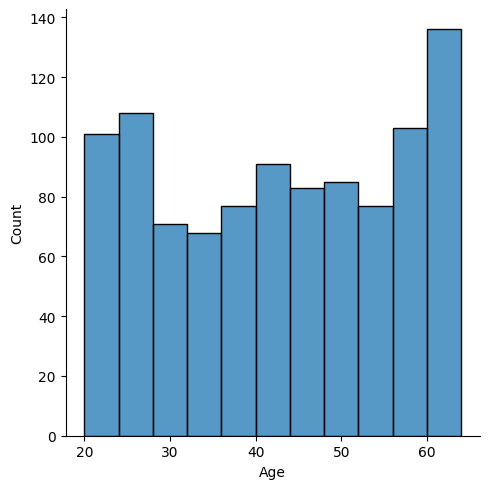

In [3]:
# sns.displot(df['Salary'])
# sns.displot(df['Experience'])
sns.displot(df['Age'])


### 2. using pandas we can see


In [4]:
df['Age'].skew()
df['Salary'].skew()
df['Experience'].skew()

np.float64(0.0010070089335874341)

### 3. Using QQ (Quantile–Quantile plot) plots it is the best way to check the distribution of the graph

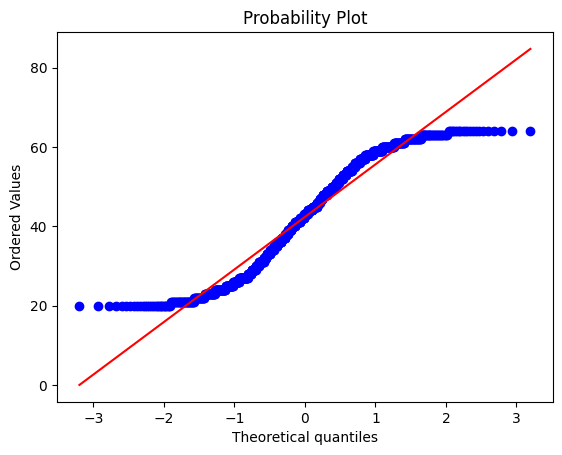

In [5]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(df['Age'], dist="norm", plot=plt)
plt.show()

###

### i. Log Transform

In [ ]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [ ]:
# here we given log1p to handle the zeroes values data 
trf = FunctionTransformer(func=np.log1p) 


In [ ]:
# we can also tranform using numpy
log_transformed = np.log1p(df[['Age','Experience','Salary']])
log_transformed


,Age,Experience,Salary
0,4.158883,2.197225,11.345938
1,4.094345,2.484907,11.867744
2,4.127134,3.367296,11.490693
3,3.828641,3.401197,11.480771
4,3.295837,3.258097,11.791759
...,...,...,...
995,3.258097,2.197225,11.077275
996,3.433987,3.218876,11.218141
997,3.806662,2.944439,11.494843
998,3.465736,3.332205,11.594929


In [ ]:
# using scikit learn
log_transformed1 = trf.fit_transform(df[['Age','Experience','Salary']])
log_transformed1

,Age,Experience,Salary
0,4.158883,2.197225,11.345938
1,4.094345,2.484907,11.867744
2,4.127134,3.367296,11.490693
3,3.828641,3.401197,11.480771
4,3.295837,3.258097,11.791759
...,...,...,...
995,3.258097,2.197225,11.077275
996,3.433987,3.218876,11.218141
997,3.806662,2.944439,11.494843
998,3.465736,3.332205,11.594929


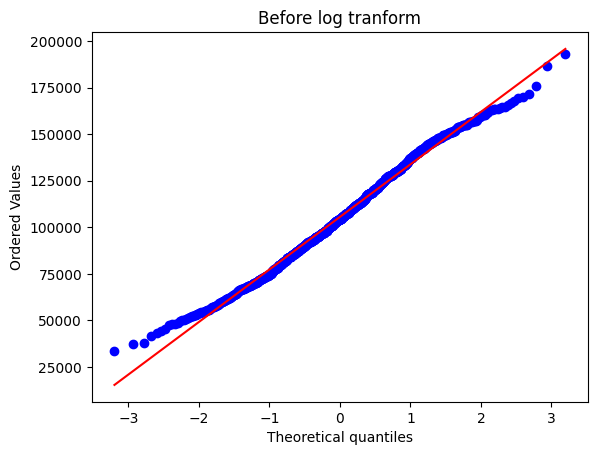

In [44]:
stats.probplot(df['Salary'], dist="norm", plot=plt)
plt.title("Before log tranform")
plt.show()



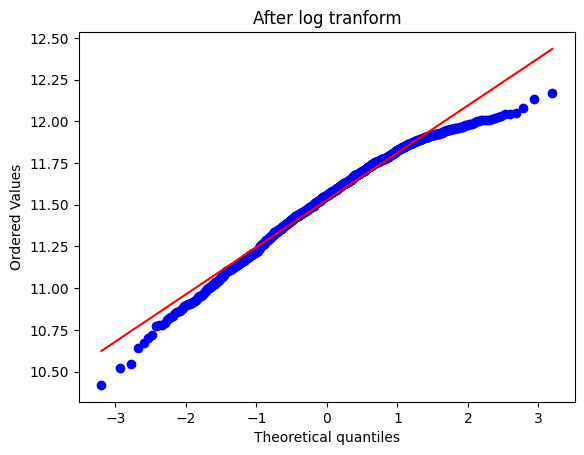

In [43]:
stats.probplot(log_transformed['Salary'], dist="norm", plot=plt)
plt.title("After log tranform")
plt.show()

### ii. Reciprocal tranform 

In [46]:
rp = FunctionTransformer(func=lambda x: 1/x)

In [48]:
reciprocal_tranform = rp.fit_transform(df[['Experience','Age','Salary']])
reciprocal_tranform

,Experience,Age,Salary
0,0.125000,0.015873,0.000012
1,0.090909,0.016949,0.000007
2,0.035714,0.016393,0.000010
3,0.034483,0.022222,0.000010
4,0.040000,0.038462,0.000008
...,...,...,...
995,0.125000,0.040000,0.000015
996,0.041667,0.033333,0.000013
997,0.055556,0.022727,0.000010
998,0.037037,0.032258,0.000009


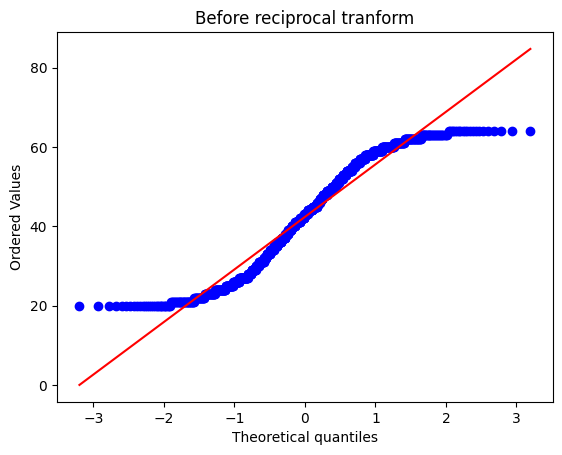

In [64]:
stats.probplot(df['Age'], dist="norm", plot=plt)
plt.title("Before reciprocal tranform")
plt.show()


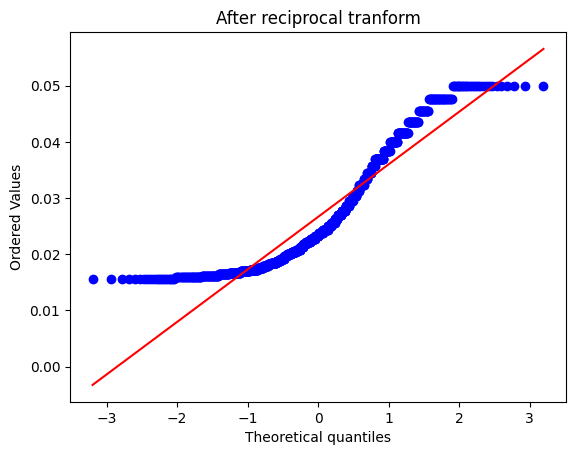

In [63]:
stats.probplot(reciprocal_tranform['Age'], dist="norm", plot=plt)
plt.title("After reciprocal tranform")
plt.show()

### iii.Square Transform

In [ ]:
# both are same 
st = FunctionTransformer(func=lambda x : x**2)
st2 = FunctionTransformer(np.square)

In [60]:
sqaure_transform = st.fit_transform(df[['Age','Experience']])
sqaure_transform

,Age,Experience
0,3969,64
1,3481,121
2,3721,784
3,2025,841
4,676,625
...,...,...
995,625,64
996,900,576
997,1936,324
998,961,729


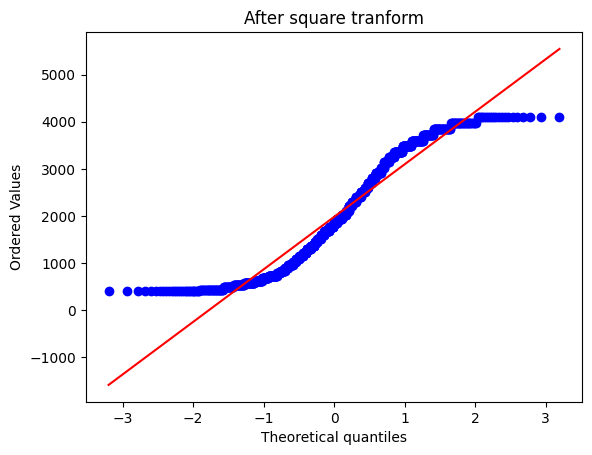

In [62]:
stats.probplot(sqaure_transform['Age'], dist="norm", plot=plt)
plt.title("After square tranform")
plt.show()

### iv. SquareRoot transform


In [ ]:
# both are same 
sr = FunctionTransformer(func= lambda x : x**0.5)
sr2 =FunctionTransformer(np.sqrt)

In [68]:
sqareroot_transform = sr.fit_transform(df[['Age','Experience','Salary']])
sqareroot_transform

,Age,Experience,Salary
0,7.937254,2.828427,290.895262
1,7.681146,3.316625,377.612574
2,7.810250,5.291503,312.730324
3,6.708204,5.385165,311.182698
4,5.099020,5.000000,363.535124
...,...,...,...
995,5.000000,2.828427,254.329294
996,5.477226,4.898979,272.888631
997,6.633250,4.242641,313.380003
998,5.567764,5.196152,329.461565


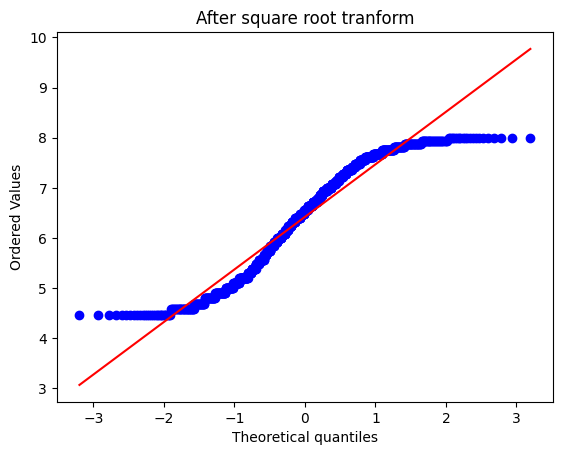

In [70]:
stats.probplot(sqareroot_transform['Age'], dist="norm", plot=plt)
plt.title("After square root tranform")
plt.show()

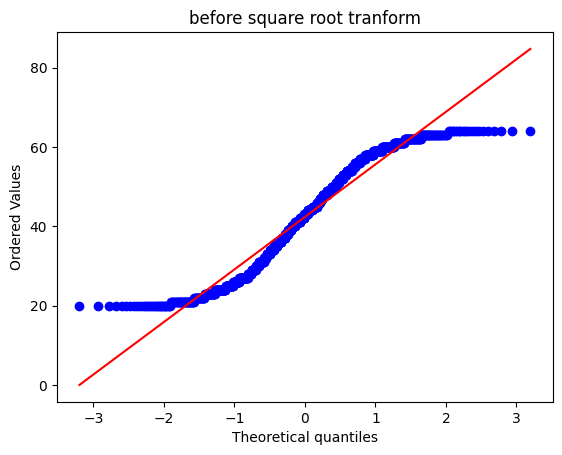

In [71]:
stats.probplot(df['Age'], dist="norm", plot=plt)
plt.title("before square root tranform")
plt.show()

### Conclusion
1️⃣ Log Transformation
When to use
Data is highly right-skewed
Large values dominate the dataset
Example: income, salary, population
Condition
x>0


2️⃣ Square Root Transformation
When to use
Data is moderately right-skewed
Used when skewness is not extremely large


3️⃣ Cube Root Transformation
When to use
Works with both positive and negative values
used when dataset contains negative numbers


4️⃣ Reciprocal Transformation
When to use
When very large values dominate
To strongly reduce skewness


5️⃣ Square Transformation
When to use
When you want to increase differences between values
Often used in feature engineering


6️⃣ Exponential Transformation
When to use
When relationships grow very rapidly
Common in scientific or financial growth models